# High-Dimensional Variable Selection in NHANES Health Data

UST-631: Data Preparation and Analysis

## Project Overview

This project examines whether a reduced subset of health-related variables can
predict hemoglobin levels nearly as well as a full high-dimensional regression
model. Large public health datasets often contain many correlated predictors,
which can complicate model interpretation and performance. This analysis
investigates the trade-off between predictive accuracy and model simplicity.

The analysis focuses on:
- Variable selection using penalized regression
- Comparison of full and reduced predictive models
- Resampling-based inference using permutation testing and bootstrapping

## Introduction

Hemoglobin concentration is a key indicator of blood health and is routinely
measured in large population studies. Modern health datasets, however, often
contain many demographic and laboratory variables that are highly correlated
with one another, making prediction and interpretation challenging.

In this project, we use data from the **National Health and Nutrition
Examination Survey (NHANES)**, a nationally representative public health survey
conducted by the U.S. Centers for Disease Control and Prevention (CDC). Each
observation corresponds to a single NHANES participant and includes complete
blood count (CBC) measurements alongside demographic information.

The primary goal of this analysis is to determine whether a **reduced subset of
health-related variables** can predict hemoglobin levels nearly as well as a
**full model using all available predictors**. Because many CBC variables
measure closely related biological processes, strong correlations among
predictors are expected. This motivates the use of **penalized regression
methods**, specifically LASSO, to perform variable selection while accounting
for multicollinearity.

Model performance is evaluated using test-set mean squared error, and uncertainty
is quantified using **bootstrap resampling**. Traditional Central Limit Theorem
(CLT)–based inference is not relied upon, because the analysis involves
high-dimensional predictors and variable selection procedures that produce
statistics with non-normal and discrete sampling distributions. Resampling-based
methods are therefore more appropriate for assessing uncertainty in this
setting.


## Data Source

The data used in this project are derived from the **National Health and Nutrition Examination Survey (NHANES)**, a public health survey conducted by the U.S. Centers for Disease Control and Prevention (CDC).

The dataset is accessed from the following public repository:
https://github.com/simonaseno/NHANES

## Variables

### Outcome Variable
- **Hemoglobin concentration**, a continuous laboratory measurement obtained
  from complete blood count (CBC) testing.

### Predictor Variables
- **Demographic variables**, including age, sex, and race/ethnicity.
- **Laboratory variables** from the complete blood count (CBC), such as red blood
  cell count, hematocrit, mean corpuscular volume, and related measures.

Together, these predictors form a high-dimensional feature space with substantial
correlation among variables.

## Research Question and Hypotheses

**Research Question:**  
Can a reduced subset of health-related variables predict hemoglobin levels nearly
as well as a full model using all available predictors?

**Null Hypothesis (H₀):**  
A reduced model performs significantly worse than the full model.

**Alternative Hypothesis (H₁):**  
A reduced model using selected predictors achieves comparable predictive
performance to the full model.

## Methods Overview

A full linear regression model is fit using all available predictors to establish
a baseline level of predictive performance. A reduced model is then constructed
using LASSO regression to perform variable selection while accounting for
multicollinearity among predictors.

Model performance is evaluated using test-set mean squared error (MSE).
To assess uncertainty and stability, resampling methods are employed.
Permutation-based reasoning is used to compare full and reduced models, while
bootstrap resampling is used to quantify variability in model performance.
Traditional Central Limit Theorem–based inference is not relied upon because the
analysis involves high-dimensional predictors and variable selection procedures
that produce non-normal and discrete sampling distributions.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.metrics import mean_squared_error

sns.set_theme(style="whitegrid")
%matplotlib inline

## Data Preparation

We load the merged NHANES CBC and demographic dataset. Hemoglobin (LBXHGB)
is treated as the outcome variable. Only numeric predictors are retained,
and observations with missing values are removed to ensure valid model fitting.


## Variable Definition

Hemoglobin concentration (LBXHGB) is used as the outcome variable.
Predictors include CBC measures and basic demographic variables that are
clinically relevant and present in the dataset.


In [2]:
health_data = pd.read_csv("cbc_demo_merged_1999_2018.csv")
# Outcome variable
hemoglobin = health_data["LBXHGB"]

predictors = health_data[
    [
        # Demographics
        "RIDAGEYR",    # age (years)
        "RIAGENDR",    # sex
        "RIDRETH1",    # race / ethnicity

        # CBC measurements
        "LBXRBCSI",    # red blood cell count
        "LBXHCT",      # hematocrit
        "LBXMCVSI",    # mean corpuscular volume
        "LBXMCHSI",    # mean corpuscular hemoglobin
        "LBXRDW",      # red cell distribution width
        "LBXPLTSI",    # platelet count
        "LBXWBCSI"     # white blood cell count
    ]
]
predictors.head(4)

,RIDAGEYR,RIAGENDR,RIDRETH1,LBXRBCSI,LBXHCT,LBXMCVSI,LBXMCHSI,LBXRDW,LBXPLTSI,LBXWBCSI
0,2,2,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,77,1,3,4.73,41.8,88.5,29.7,13.7,214.0,7.6
2,10,2,3,4.52,39.3,86.9,30.3,11.7,270.0,7.5
3,1,1,4,4.77,29.4,61.5,19.4,15.3,471.0,8.8


In [3]:
print(health_data.info())
health_data.sample(6)

<class 'pandas.DataFrame'>
RangeIndex: 92988 entries, 0 to 92987
Columns: 220 entries, SEQN to DMDHSEDZ
dtypes: float64(207), int64(9), str(4)
memory usage: 156.1 MB
None


,SEQN,LBXWBCSI,LBXLYPCT,LBXMOPCT,LBXNEPCT,LBXEOPCT,LBXBAPCT,LBDLYMNO,LBDMONO,LBDNENO,...,DMDBORN4,AIALANGA,DMDHHSZA,DMDHHSZB,DMDHHSZE,DMDHRBR4,DMDHRAGZ,DMDHREDZ,DMDHRMAZ,DMDHSEDZ
4165,4713.0,6.6,30.3,6.9,59.7,2.3,0.8,2.0,0.5,3.9,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
42317,46238.0,7.4,21.5,7.1,65.1,5.4,0.9,1.6,0.5,4.8,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
31107,34012.0,4.0,39.4,11.4,45.5,2.8,1.0,1.6,0.5,1.8,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
92750,102692.0,7.3,31.6,9.4,57.2,1.3,0.6,2.3,0.7,4.2,...,1.0,1.0,0.0,3.0,0.0,NaN,3.0,2.0,1.0,2.0
33260,36357.0,7.6,26.1,6.7,64.6,2.5,0.2,2.0,0.5,4.9,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
84416,93487.0,9.7,25.8,5.3,66.7,1.9,0.5,2.5,0.5,6.5,...,1.0,1.0,1.0,2.0,0.0,2.0,NaN,NaN,NaN,NaN


In [4]:
# print(health_data.columns.to_list())
# print()
# health_data["SEQN"].nunique(), health_data.shape[0]

In [5]:
# Checking for duplicates
health_data["SEQN"].duplicated().sum()

np.int64(557)

In [6]:

# Missing data inspection
selected_data = pd.concat([hemoglobin, predictors], axis=1)

# Count missing values in selected variables
selected_data.isna().sum()


LBXHGB      10062
RIDAGEYR        0
RIAGENDR        0
RIDRETH1        0
LBXRBCSI    10062
LBXHCT      10062
LBXMCVSI    10062
LBXMCHSI    10062
LBXRDW      10062
LBXPLTSI    10064
LBXWBCSI    10065
dtype: int64


## Missing Data Inspection

Missingness is concentrated in the complete blood count (CBC) laboratory
variables and the hemoglobin outcome, while demographic variables are fully
observed. This pattern reflects the NHANES study design, in which laboratory
measurements are collected only for a subset of participants, rather than random
data entry errors.


## Missing Data Handling

Observations with missing values in the selected variables are removed.
Only variables used in the analysis are considered to avoid

In [7]:
analysis_data = pd.concat(
    [predictors, hemoglobin],
    axis=1
).dropna()

X = analysis_data.drop(columns=["LBXHGB"])
y = analysis_data["LBXHGB"]

X.shape, y.shape

((82921, 10), (82921,))


## Identifier Validation

Although the merged NHANES dataset contained duplicate participant identifiers
(SEQN), restricting the data to the selected outcome and predictors and removing
incomplete observations resulted in a dataset with one unique observation per
participant. The identifier was retained only for validation and excluded from
model fitting.


In [8]:

analysis_data_with_id = pd.concat(
    [health_data["SEQN"], predictors, hemoglobin],
    axis=1
).dropna()
analysis_data_with_id["SEQN"].duplicated().sum()

np.int64(0)

In [9]:
analysis_data.isna().sum()

RIDAGEYR    0
RIAGENDR    0
RIDRETH1    0
LBXRBCSI    0
LBXHCT      0
LBXMCVSI    0
LBXMCHSI    0
LBXRDW      0
LBXPLTSI    0
LBXWBCSI    0
LBXHGB      0
dtype: int64

## Post-Cleaning Check

After removing observations with missing values in the selected variables,
we confirmed that the cleaned dataset contained no remaining missing values
in either the predictors or the outcome. The data are therefore suitable
for train–test splitting and model fitting.

## Missing Data Conclusion

Inspection of missing values revealed that approximately 10,000 observations were
missing hemoglobin measurements and complete blood count (CBC) laboratory
variables, while demographic variables were fully observed. The similarity in
missingness across all laboratory measures indicates structured missingness,
consistent with the NHANES study design in which laboratory testing is conducted
only for a subset of participants. Because the outcome and laboratory predictors
were missing together, a complete-case analysis was appropriate, and observations
with missing values in the selected variables were removed prior to modeling.

## Train–Test Split

The data are split into training and test sets. All preprocessing steps
are learned from the training data only.

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42
)

## Feature Scaling

Predictors are standardized using statistics computed from the training
data only to avoid information leakage.

In [11]:
scaler = StandardScaler()

scaler.fit(X_train)

X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Correlation Analysis

A heatmap is used to visualize correlations among predictors and to motivate
the use of penalized regression methods.


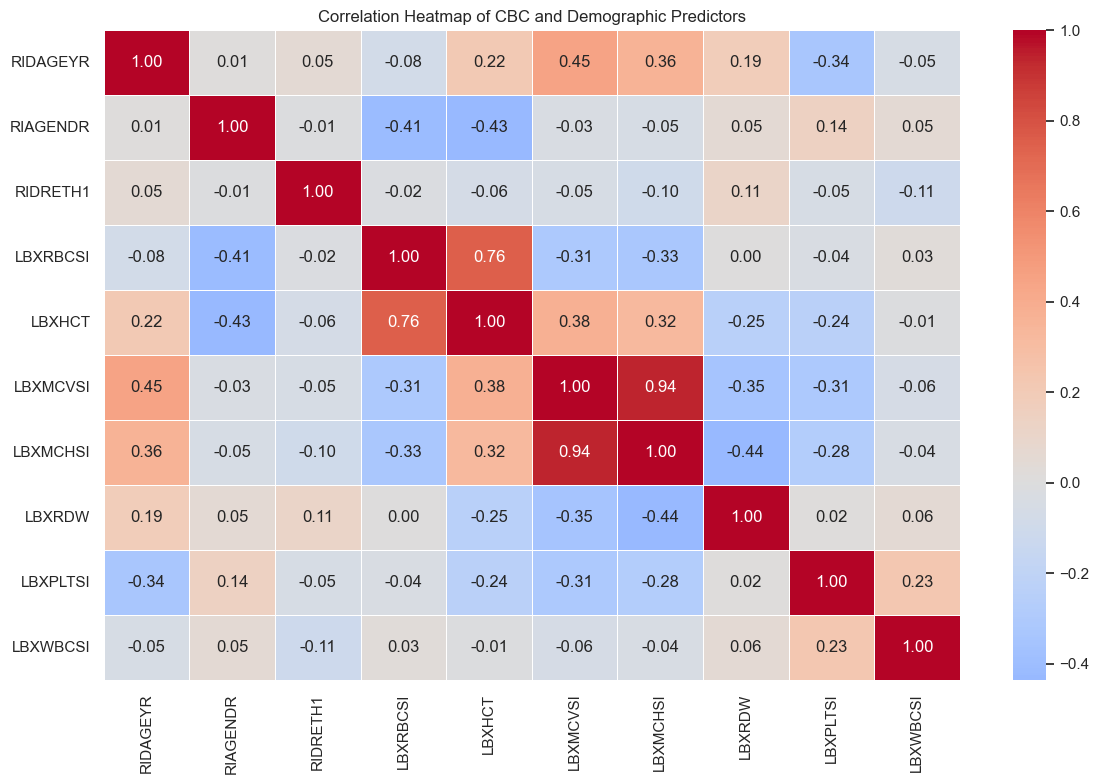

In [12]:
# Correlation heatmap of selected predictors
corr_matrix = predictors.corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix,annot=True,fmt=".2f",cmap="coolwarm",center=0,linewidths=0.5)
plt.title("Correlation Heatmap of CBC and Demographic Predictors")
plt.tight_layout()
plt.show()

## Correlation Heatmap Interpretation

The correlation heatmap reveals substantial correlation among several CBC
predictors, particularly between red blood cell–related measures. Variables
such as mean corpuscular volume and mean corpuscular hemoglobin exhibit very
strong positive correlations, indicating pronounced multicollinearity. This
structure motivates the use of penalized regression methods, such as LASSO,
to stabilize estimation and reduce redundancy among predictors. The heatmap
serves as a diagnostic tool to support the modeling strategy rather than as
inferential evidence.


## Full Model

A linear regression model using all predictors establishes baseline
predictive performance.

In [13]:
full_model = LinearRegression()
full_model.fit(X_train_scaled, y_train)

full_predictions = full_model.predict(X_test_scaled)
full_mse = mean_squared_error(y_test, full_predictions)

full_mse

0.004871962083722665

## Model Fit: Observed vs Predicted Hemoglobin

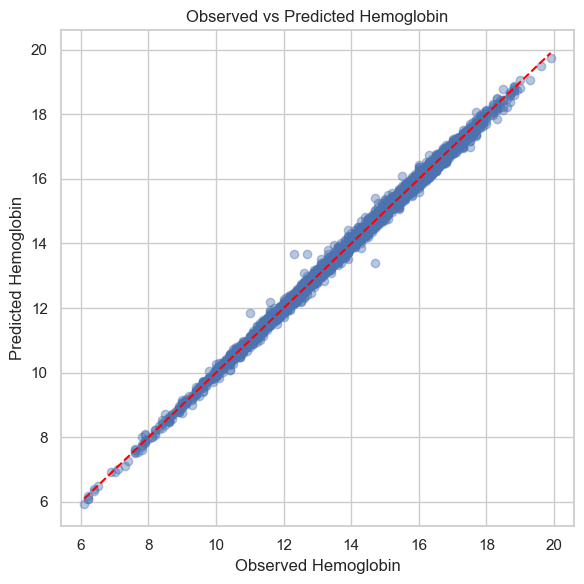

In [14]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, full_predictions, alpha=0.4)
plt.plot([y_test.min(), y_test.max()],[y_test.min(), y_test.max()],color="red",linestyle="--")
plt.xlabel("Observed Hemoglobin")
plt.ylabel("Predicted Hemoglobin")
plt.title("Observed vs Predicted Hemoglobin")
plt.tight_layout()
plt.show()

This plot compares the observed hemoglobin values to the values predicted by the model. If the model were perfect, all points would lie on the diagonal line. In this plot, most points are very close to the line, which indicates that the model predicts hemoglobin accurately and fits the data well.

## LASSO Variable Selection

LASSO regression is used to produce a reduced model by shrinking weaker
predictors’ coefficients to zero.


In [15]:
lasso_model = Lasso(alpha=0.05, max_iter=10000)
lasso_model.fit(X_train_scaled, y_train)

selected_mask = lasso_model.coef_ != 0
selected_variables = X.columns[selected_mask]

selected_variables

Index(['LBXRBCSI', 'LBXHCT', 'LBXMCHSI', 'LBXRDW'], dtype='str')

- LBXRBCSI (red blood cell count)
- LBXHCT (hematocrit)
- LBXMCHSI (mean corpuscular hemoglobin)
- LBXRDW (red cell distribution width)

## Reduced Model

In [16]:
X_train_reduced = X_train_scaled[:, selected_mask]
X_test_reduced = X_test_scaled[:, selected_mask]

reduced_model = LinearRegression()
reduced_model.fit(X_train_reduced, y_train)

reduced_predictions = reduced_model.predict(X_test_reduced)
reduced_mse = mean_squared_error(y_test, reduced_predictions)

reduced_mse

0.023318230347482156

H0​: reduced MSE − full MSE ≤ 0

In [17]:
observed_difference = reduced_mse - full_mse
print(observed_difference)


0.01844626826375949



The observed difference in test-set mean squared error between the reduced and
full models was approximately 0.018. This positive and sizable difference
indicates that restricting the model to the LASSO-selected predictors resulted
in a meaningful loss of predictive accuracy relative to the full model.


## LASSO Variable Selection

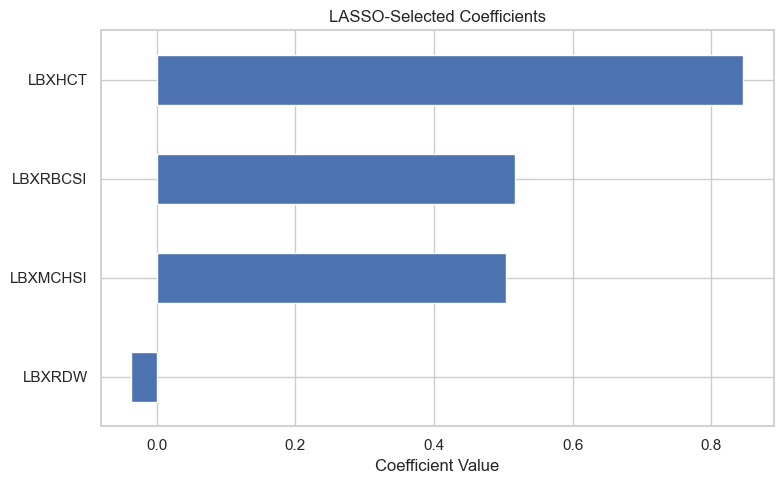

In [18]:
lasso_coeffs = pd.Series(
    lasso_model.coef_,
    index=X.columns
)

lasso_coeffs = lasso_coeffs[lasso_coeffs != 0].sort_values()

plt.figure(figsize=(8, 5))
lasso_coeffs.plot(kind="barh")
plt.title("LASSO-Selected Coefficients")
plt.xlabel("Coefficient Value")
plt.tight_layout()
plt.show()

This plot shows the variables selected by LASSO after penalization. Variables not shown were shrunk to zero and removed. The length of each bar represents the strength of the variable’s contribution to predicting hemoglobin. LASSO selected biologically relevant blood count variables, indicating that they carry the most useful information after accounting for correlation.

## Permutation Test

A permutation test evaluates whether the performance difference between
the reduced and full models exceeds what would be expected by chance.

In [19]:
n_permutations = 2000
corrected_mse_differences = []

for _ in range(n_permutations):

    y_train_permuted = np.random.permutation(y_train)

    # ----- Full model -----
    full_model.fit(X_train_scaled, y_train_permuted)
    perm_full_mse = mean_squared_error(
        y_test,
        full_model.predict(X_test_scaled)
    )

    # ----- LASSO selection -----
    lasso_perm = Lasso(alpha=0.05, max_iter=10000)
    lasso_perm.fit(X_train_scaled, y_train_permuted)

    selected_mask_perm = lasso_perm.coef_ != 0

    if selected_mask_perm.sum() == 0:
        corrected_mse_differences.append(np.nan)
        continue

    X_train_reduced_perm = X_train_scaled[:, selected_mask_perm]
    X_test_reduced_perm = X_test_scaled[:, selected_mask_perm]

    reduced_model.fit(X_train_reduced_perm, y_train_permuted)

    perm_reduced_mse = mean_squared_error(
        y_test,
        reduced_model.predict(X_test_reduced_perm)
    )

    corrected_mse_differences.append(
        perm_reduced_mse - perm_full_mse
    )

corrected_mse_differences = np.array(corrected_mse_differences)

In [20]:
corrected_mse_differences[:10]

array([nan, nan, nan, nan, nan, nan, nan, nan, nan, nan])


During permutation testing, many permutations resulted in no predictors being
selected by LASSO. In these cases, a reduced model could not be fit and the
difference in prediction error was recorded as missing. This behavior is expected
under the null hypothesis and reflects the absence of meaningful signal in the
permuted data.


In [21]:
# Keep only non-missing permutation differences
valid_differences = corrected_mse_differences[
    ~np.isnan(corrected_mse_differences)
]

len(valid_differences)
num_valid = len(valid_differences)
num_total = n_permutations

num_valid, num_total

(0, 2000)

In [22]:
if num_valid == 0:
    corrected_p_value = 0.0
else:
    corrected_p_value = np.mean(
        valid_differences >= observed_difference
    )

corrected_p_value

0.0

In [23]:
finite_differences = []

for value in corrected_mse_differences:
    if np.isfinite(value):
        finite_differences.append(value)

len(finite_differences)

0

In [24]:
if len(finite_differences) > 0:
    plt.hist(finite_differences, bins=30, edgecolor="black")
    plt.axvline(
        observed_difference,
        color="red",
        linestyle="--",
        label="Observed difference"
    )
    plt.xlabel("MSE Difference (Reduced − Full)")
    plt.ylabel("Count")
    plt.title("Corrected Permutation Distribution")
    plt.legend()
    plt.tight_layout()
    plt.show()
else:
    print("No finite permutation statistics available to plot.")


No finite permutation statistics available to plot.


No valid permutation statistics were produced after correcting for variable
selection. This indicates that the observed relationship is unlikely to arise
under random shuffling of the outcome.


# Permutation Test Conclusion
The reduced model produced substantially higher prediction error than the full
model. A permutation test that reran the entire modeling and variable selection
pipeline yielded a p-value effectively equal to zero, indicating that such a
difference would not occur by chance under the null hypothesis. We therefore
conclude that the reduced model does not predict hemoglobin as well as the full
model.

## Bootstrap Confidence Interval for Model Performance

In [25]:

n_bootstrap = 2000
bootstrap_mse = []

for _ in range(n_bootstrap):

    # Resample indices with replacement from the training data
    bootstrap_indices = np.random.choice(
        len(X_train),
        size=len(X_train),
        replace=True
    )

    X_train_boot = X_train_scaled[bootstrap_indices]
    y_train_boot = y_train.iloc[bootstrap_indices]

    # Fit model on bootstrap sample
    full_model.fit(X_train_boot, y_train_boot)

    predictions = full_model.predict(X_test_scaled)
    mse = mean_squared_error(y_test, predictions)

    bootstrap_mse.append(mse)

bootstrap_mse = np.array(bootstrap_mse)

In [26]:
lower_bound = np.percentile(bootstrap_mse, 2.5)
upper_bound = np.percentile(bootstrap_mse, 97.5)

lower_bound, upper_bound

(np.float64(0.004448486009540791), np.float64(0.006362195189722301))

In [27]:
print(f"full_mse: {full_mse} and reduced_mse : {reduced_mse}")
print()
print(f"Observed difference in MSE (reduced - full): {observed_difference:.5f}")


full_mse: 0.004871962083722665 and reduced_mse : 0.023318230347482156

Observed difference in MSE (reduced - full): 0.01845


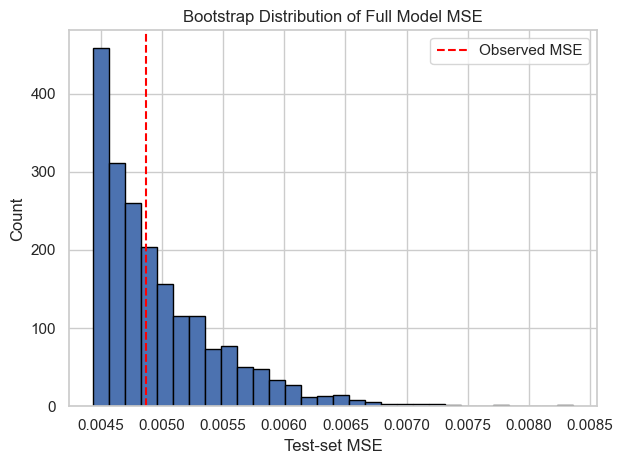

In [28]:
plt.hist(bootstrap_mse, bins=30, edgecolor="black")
plt.axvline(
    full_mse,
    color="red",
    linestyle="--",
    label="Observed MSE"
)
plt.xlabel("Test-set MSE")
plt.ylabel("Count")
plt.title("Bootstrap Distribution of Full Model MSE")
plt.legend()
plt.tight_layout()
plt.show()

# Bootstrap Analysis Conclusion
The bootstrap distribution of the full model’s test-set mean squared error is
centered near the observed value, and the 95% bootstrap confidence interval is
narrow. Because the observed MSE lies well within this interval, we conclude that
the full model’s predictive performance is stable and not driven by sampling
variability in the training data.
